# Experiment 1a — does Autostep hold useless connections down?

**Problem.** Stationary 2-task multi-GEOFF: two independent GEOFF teachers, each with 2 inputs and
1 output, plus $N(0, 1)$ observation noise. Inputs and outputs are laid out task-major, and the
loss is a plain sum of per-output squared errors, so nothing about the grouping leaks through the
loss. Training is online, one fresh sample per step. Per-output MSE is 1.0 for an optimal predictor
(the noise variance) and 2.0 for the mean predictor.

**Network.** A two-layer MLP with 4 LTU hidden units — a step function forward with a
sigmoid-derivative surrogate backward, so the learner's units are the same kind as the teacher's.
Connectivity is a 0/1 mask multiplied into the weights: the base structure is block-sparse, each
hidden unit wired only to its own task's inputs and outputs, and on top of it half of the hidden
units are additionally wired to *every* other-task output, the other half to every other-task
input. Each of those extra connections crosses tasks and so is **useless by construction**; that
useful/useless split is what the figures measure. Each layer also gets a constant-1 input column,
so biases are ordinary weights inside the weight matrix, which is what Autostep's per-output-unit
normalizer needs. Input weights start uniform on `INIT_W1_RANGE`; output weights and
biases start at 0.

**Runs.** SGD + momentum at one static step-size (nothing but $|w|$ can separate the groups),
Autostep variant B (normalize by the squared value of each weight's source unit), and variant B
with a subgradient L1 penalty. Under Autostep every connection starts at step-size `INIT_LR`
(the bias columns at `INIT_BIAS_LR`): useful ones should climb off it, useless ones should stay
near it.

In [13]:
import os
import sys

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import seaborn as sns

from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.analysis.analysis_utils import get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import (
    USEFUL, USELESS, MaskedTwoLayerMLP, block_sparse_masks, connection_labels, contaminate_masks,
    gather_at, halves_group_ids, slot_ids, subsample_indices,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

In [14]:
# --- Problem ---
N_TASKS = 2
N_FEATURES_PER_TASK = 2
N_OUTPUTS_PER_TASK = 1
NOISE_STD = 1.0

# --- Network ---
N_HIDDEN = 4
ACTIVATION = 'ltu'
USE_BIAS = True
INIT_W1_RANGE = (-0.0001, 0.0001)      # input weights ~ U(range); output weights and biases at 0

# --- Optimizers ---
INIT_LR = 1e-8                   # starting step-size of every connection under Autostep ...
INIT_BIAS_LR = 1e-5              # ... except each layer's bias column, which starts here
META_LR = 0.02
L1_COEFF = 0.001
SGD_LR = 0.0005                   # tuned so the effective step-size lr / (1 - momentum) stays stable
SGD_MOMENTUM = 0.9

# --- Training and recording ---
NUM_STEPS = 1_000_000
N_SEEDS = 30                     # vmapped into one scan; scan width is nearly free
N_SNAPSHOTS = 250                # recording points per run, for both the loss and the connections
N_TRACES = 30                    # individual connections followed per layer per group
BASE_SEED = 0

# --- Derived ---
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK
IRREDUCIBLE_MSE = NOISE_STD ** 2         # per-output MSE of an optimal predictor
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0     # the mean predictor sits 1 above it
LAYERS = ('w1', 'w2')
LAYER_NAMES = ('input layer (hidden $\\leftarrow$ inputs)',
               'output layer (outputs $\\leftarrow$ hidden)')
GROUPS = (USEFUL, USELESS)               # biases are trained, but sit outside this comparison
GROUP_NAMES = ('useful (same task)', 'useless (cross task)')
GROUP_COLORS = ('#3b6fb0', '#c0392b')
SGD_LABEL = f'SGD + momentum (lr {SGD_LR:g}, m {SGD_MOMENTUM:g})'

In [15]:
base_masks, hidden_task_ids = block_sparse_masks(
    N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, N_HIDDEN, bias=USE_BIAS)
input_task_ids = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
output_task_ids = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

# Contaminate: half the hidden units gain every cross-task output, the other half every cross-task
# input. Labels mark each position useful / useless / bias, and never change during a run.
masks = contaminate_masks(base_masks, hidden_task_ids, halves_group_ids(hidden_task_ids),
                          input_task_ids, output_task_ids)
labels = connection_labels(masks, hidden_task_ids, input_task_ids, output_task_ids)

# Which individual connections the figures follow. Fixed once, outside `jit`.
trace_idxs = {l: {g: subsample_indices(labels[l], g, N_TRACES, seed=BASE_SEED) for g in GROUPS}
              for l in LAYERS}

for layer in LAYERS:
    counts = '   '.join(f'{name} {int((labels[layer] == g).sum()):3d}'
                        for g, name in zip(GROUPS, GROUP_NAMES))
    print(f'{layer}:  {counts}')

w1:  useful (same task)   8   useless (cross task)   4
w2:  useful (same task)   4   useless (cross task)   2


## Learner

In [16]:
class Learner(eqx.Module):
    """The masked MLP and its optimizer: Autostep variant B, or SGD + momentum as the baseline.

    Masked-out connections are inert either way — the mask zeroes their loss gradient, so their
    weight and optimizer state never leave 0.
    """
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    autostep: bool = eqx.field(static=True)
    l1: float = eqx.field(static=True)

    def __init__(self, key, optimizer, autostep, l1=0.0):
        # Input weights uniform on `INIT_W1_RANGE`, output weights and biases at 0. Masked-out
        # positions are held at exactly 0, as `MaskedTwoLayerMLP`'s own init does. A zero output
        # layer only stalls the input layer for one step (variant B's normalizer does not go
        # through the prediction gradients, which a zero layer would kill).
        model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, bias=USE_BIAS, key=key)
        w1 = jax.random.uniform(key, model.weights['w1'].shape, minval=INIT_W1_RANGE[0],
                                maxval=INIT_W1_RANGE[1])
        if USE_BIAS:
            w1 = w1.at[:, -1].set(0.0)
        self.model = tree_replace(model, weights={'w1': w1 * masks['w1'],
                                                  'w2': jnp.zeros_like(model.weights['w2'])})
        self.optimizer = optimizer

        opt_state = optimizer.init(self.model.weights)
        if autostep and USE_BIAS:
            # Give the bias columns their own starting step-size. `init_beta` stays at `INIT_LR`;
            # it is only read when `shadow_weight_threshold_factor` is set, which it is not here.
            opt_state = opt_state._replace(beta={
                k: b.at[:, -1].set(jnp.log(INIT_BIAS_LR)) for k, b in opt_state.beta.items()})
        self.opt_state = opt_state
        self.autostep = autostep
        self.l1 = l1

    @property
    def step_sizes(self):
        """Per-connection step-sizes: adapted under Autostep, static under SGD."""
        if self.autostep:
            return {k: jnp.exp(self.opt_state.beta[k]) for k in LAYERS}
        return {k: jnp.full_like(w, SGD_LR) for k, w in self.model.weights.items()}

    def step(self, x, y):
        """One online update. Returns the new learner and the squared error summed over outputs."""
        def loss_fn(weights):
            out, param_inputs = tree_replace(self.model, weights=weights)(x)
            return jnp.sum((out - y) ** 2), param_inputs

        (loss, param_inputs), grads = jax.value_and_grad(loss_fn, has_aux=True)(self.model.weights)

        if self.l1 > 0.0:
            # L1 goes into the gradient Autostep consumes, so it shapes step-size adaptation too.
            # `loss` stays pure squared error, so the MSE curves stay comparable across runs.
            penalty = {k: self.l1 * jnp.sign(w) for k, w in self.model.weights.items()}
            if USE_BIAS:
                # Shrinking a bias fights the target's nonzero mean instead of pruning structure.
                penalty = {k: p.at[:, -1].set(0.0) for k, p in penalty.items()}
            grads = {k: g + penalty[k] for k, g in grads.items()}

        # Variant B treats each layer as its own linear problem, normalizing by the squared value of
        # each weight's source unit — which is exactly the `param_inputs` the forward pass returns.
        update_input = (grads, None, param_inputs) if self.autostep else grads
        updates, opt_state = self.optimizer.update(update_input, self.opt_state, self.model.weights)
        weights = {k: w + updates[k] for k, w in self.model.weights.items()}
        return tree_replace(self, model=tree_replace(self.model, weights=weights),
                            opt_state=opt_state), loss


def autostep_learner(key, l1=0.0):
    return Learner(key, optax_idbd(init_lr=INIT_LR, meta_lr=META_LR, autostep=True,
                                   version='squared_inputs'), autostep=True, l1=l1)


def sgd_learner(key):
    return Learner(key, optax.sgd(SGD_LR, momentum=SGD_MOMENTUM), autostep=False)

## Training

In [17]:
def snapshot(learner):
    """Step-size and weight of the traced connections, shaped (layer, group, trace)."""
    def traces(values):
        return jnp.stack([jnp.stack([gather_at(values[l], trace_idxs[l][g]) for g in GROUPS])
                          for l in LAYERS])

    return {'alpha': traces(learner.step_sizes),
            'w': traces(learner.model.weights)}


def train(learner, task):
    """`NUM_STEPS` of online training: every step's loss, and `N_SNAPSHOTS` + 1 snapshots."""
    def one_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(1)              # online: one sample per step
        learner, loss = learner.step(x[0], y[0])
        return (learner, task), loss

    def block(carry, _):
        snap = snapshot(carry[0])                          # start-of-block, so step 0 is recorded
        carry, losses = jax.lax.scan(one_step, carry, length=NUM_STEPS // N_SNAPSHOTS)
        return carry, (losses, snap)

    carry, (losses, snaps) = jax.lax.scan(block, (learner, task), length=N_SNAPSHOTS)
    # Snapshots then run 0, ..., NUM_STEPS once the final state is appended.
    snaps = jax.tree.map(lambda s, final: jnp.concatenate([s, final[None]]), snaps,
                         snapshot(carry[0]))
    return losses, snaps


def run(make_learner):
    """Train `N_SEEDS` independent runs — one teacher and one init each — vmapped into one scan."""
    tasks = stack_pytrees([                                # the task takes an int seed, not a key
        MultiGEOFFTask(N_TASKS, n_features_per_task=N_FEATURES_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD,
                       seed=BASE_SEED + s)
        for s in range(N_SEEDS)])
    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), N_SEEDS)
    losses, snaps = jax.jit(jax.vmap(lambda key, task: train(make_learner(key), task)))(keys, tasks)

    # Per-output MSE, averaged within each block; snapshots sit on the block edges.
    block_len = NUM_STEPS // N_SNAPSHOTS
    return {'steps': np.arange(1, N_SNAPSHOTS + 1) * block_len,
            'snap_steps': np.arange(N_SNAPSHOTS + 1) * block_len,
            'mse': np.asarray(losses, dtype=np.float32).mean(-1) / N_OUTPUTS,
            **{k: np.asarray(v) for k, v in snaps.items()}}


runs = {
    SGD_LABEL: run(sgd_learner),
    'Variant B': run(autostep_learner),
    f'Variant B + L1 {L1_COEFF:g}': run(lambda key: autostep_learner(key, l1=L1_COEFF)),
}

## Results

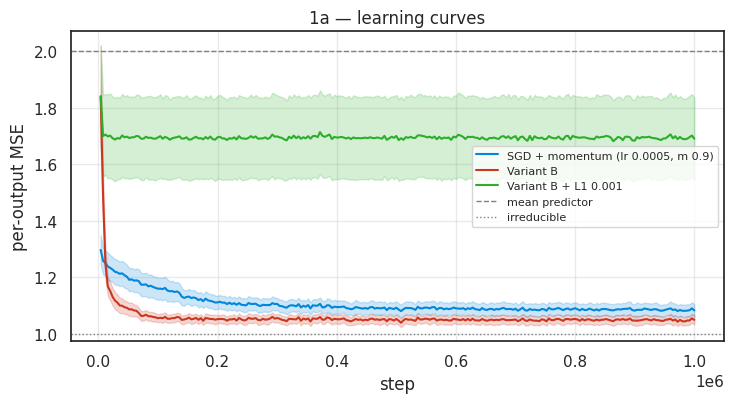

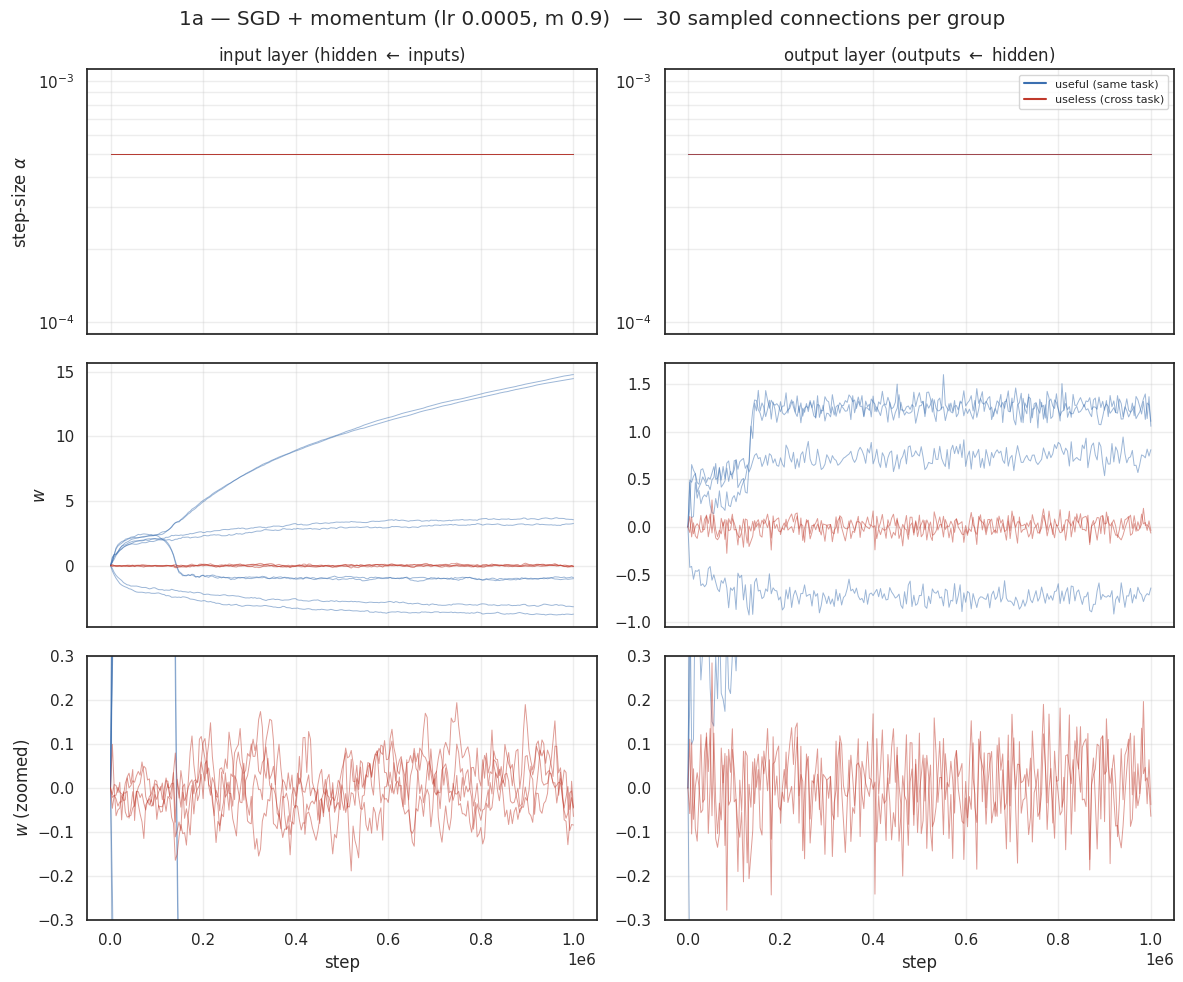

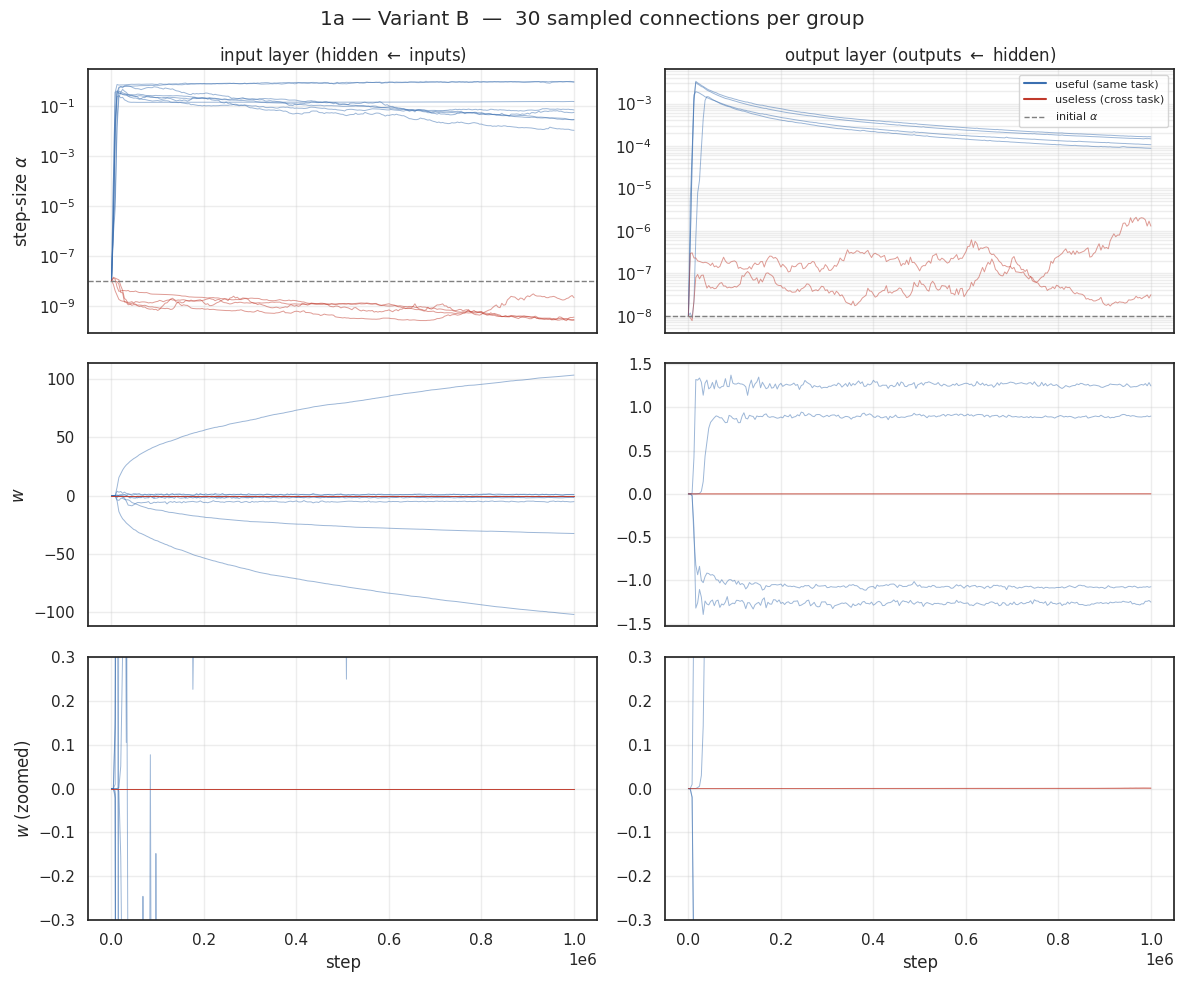

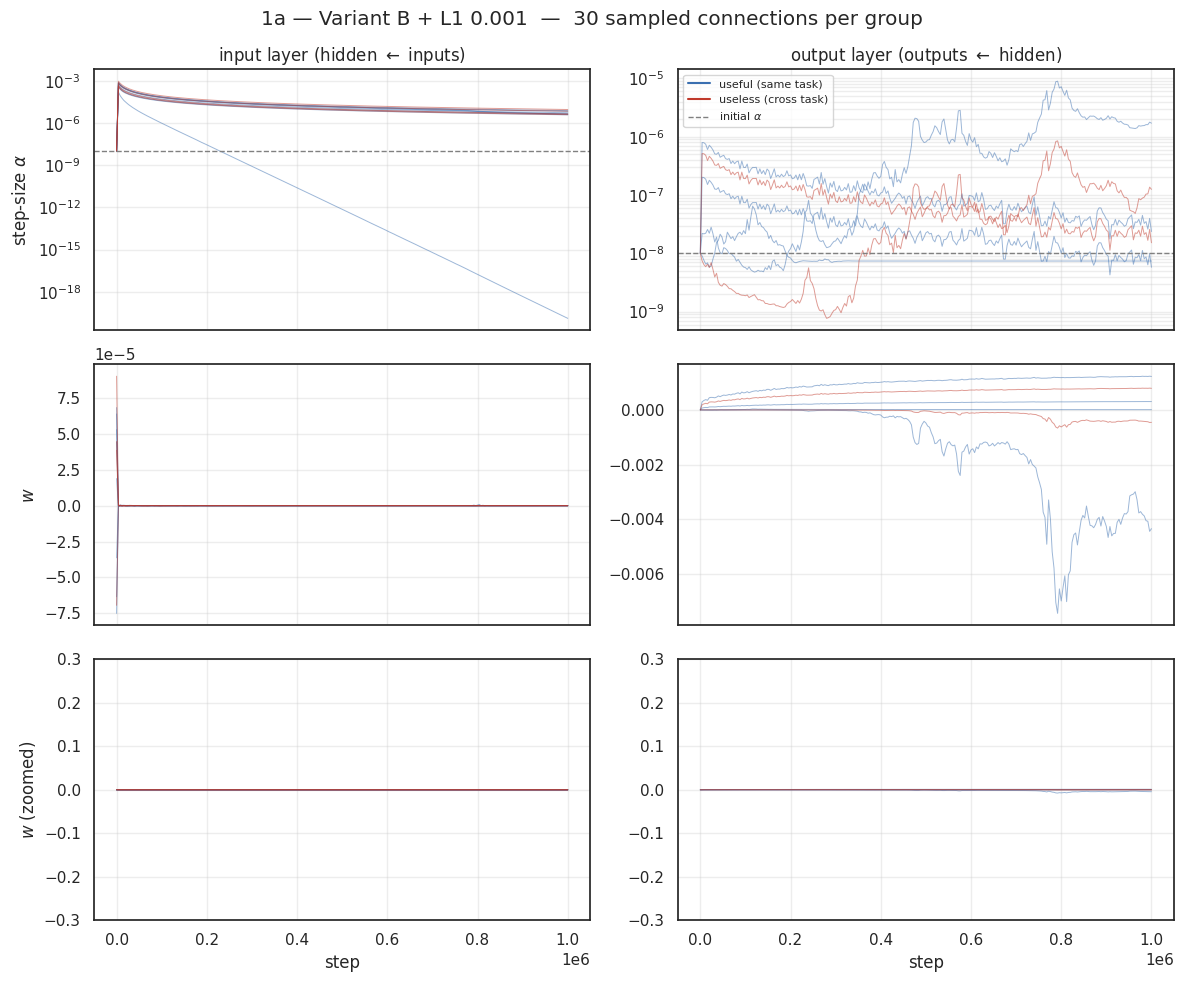

In [18]:
def plot_curves(runs):
    """Per-output MSE per run, mean +- 2 standard errors over seeds."""
    plt.figure(figsize=(7.5, 4.2))
    for (label, res), color in zip(runs.items(), get_color_palette(n=len(runs))):
        mean = res['mse'].mean(0)
        sem = res['mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(res['steps'], mean, color=color, label=label)
        plt.fill_between(res['steps'], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    plt.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor')
    plt.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible')
    plt.xlabel('step')
    plt.ylabel('per-output MSE')
    plt.title('1a — learning curves')
    plt.grid(alpha=0.4)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_connections(res, title, alpha_ref=INIT_LR):
    """One run's traced connections: step-size, weight, and weight zoomed in. One column per layer.

    `alpha_ref` marks where step-size adaptation started, and is None for SGD, which does not adapt.
    """
    rows = [('alpha', 'step-size $\\alpha$', True, None),
            ('w', '$w$', False, None),
            ('w', '$w$ (zoomed)', False, (-0.3, 0.3))]
    fig, axes = plt.subplots(len(rows), 2, figsize=(12, 10), sharex=True)
    for row, (key, ylabel, log_scale, ylim) in enumerate(rows):
        for col, layer_name in enumerate(LAYER_NAMES):
            ax = axes[row, col]
            for group, (name, color) in enumerate(zip(GROUP_NAMES, GROUP_COLORS)):
                ax.plot(res['snap_steps'], res[key][0, :, col, group], color=color, lw=0.7,
                        alpha=0.5)
                ax.plot([], [], color=color, lw=1.5, label=name)      # legend proxy
            if log_scale:
                ax.set_yscale('log')
                if alpha_ref is not None:
                    ax.axhline(alpha_ref, ls='--', c='gray', lw=1, label='initial $\\alpha$')
            if ylim is not None:
                ax.set_ylim(*ylim)
            ax.grid(alpha=0.35, which='both')
            ax.set_title(layer_name if row == 0 else '')
            ax.set_xlabel('step' if row == len(rows) - 1 else '')
            ax.set_ylabel(ylabel if col == 0 else '')
    axes[0, 1].legend(fontsize=8)
    fig.suptitle(f'1a — {title}  —  {N_TRACES} sampled connections per group')
    fig.tight_layout()
    plt.show()


plot_curves(runs)
for label, res in runs.items():
    plot_connections(res, label, alpha_ref=None if label == SGD_LABEL else INIT_LR)